In [68]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportions_ztest
import os

df = pd.read_csv("FPI-1-11-26.csv")

dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
    }

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

In [41]:
# graph style
BG         = "#1C1C1C"
BAR_BLUE   = "#0033A0"
BAR_ORANGE = "#D64309"
WHITE      = "#FFFFFF"
GREY       = "#AAAAAA"
GRIDLINE   = "#2E2E2E"

plt.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     BG,
    "text.color":         WHITE,
    "axes.labelcolor":    GREY,
    "xtick.color":        WHITE,
    "ytick.color":        WHITE,
    "axes.titlecolor":    WHITE,
    "axes.titleweight":   "bold",
    "axes.titlesize":     14,
    "grid.color":         GRIDLINE,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
})

# Introduction #

This project investigates whether the NFL's official tiebreaker rules reliably identify the "true best" team. To do this, we simulate NFL seasons using synthetic team strength data based on ESPN's Football Power Index (FPI), giving us a known "ground truth" for each team's actual quality. This allows us to directly measure how often tiebreakers pick the "stronger" team, which is something impossible to do with real data alone.

We also compare the NFL's current rules against two alternative methods: Total Margin (point differential) and Capped Margin (point differential with a per-game cap). Finally, we explore how season length and margin caps affect the accuracy of identifying the best team.

Real NFL data from 2015–2024 is used throughout to validate our simulation findings.

### Research Questions: ###
Do current tiebreakers select the stronger team?  
How much more accurate can we get with alternative methods?  
What is the optimal cap for a capped margin tiebreaker?  
How often does the #1 FPI team end up as the 1 seed?  
How does season length affect identifying the best team?  
Do simulation findings align with real NFL data?  

# Framework and Background Information #

### FPI ###
FPI (Football Power Index) is a rating system that assigns a numerical strength value to each team. Higher values indicate stronger teams. In this project, FPI is used as the core driver of game outcomes by determining the expected scoring margin between two teams. It is based on the average number of points by which a team would beat an average NFL team. The statistic is built off EPA (Expected Points Added), which assigns an "expected points" value to each and every play. 

### Game Simulation ###
Each game is simulated using a simple margin model based on team strength, home field advantage, and randomness.

The way each game is simulated depends heavily on the FPI values assigned to each team. In the model, the difference in FPI between two teams directly shifts the expected margin:

$$
\text{margin} = (FPI_1 - FPI_2) + \text{HF} + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0,1)
$$
$$
\text{HF} = \text{home field advantage}
$$

For the simulations, FPI values are generated with a mean of -0.016 and a standard deviation of 3. The mean comes from the average FPI across real seasons.  

The standard deviation of 3 was chosen after testing different values. Using the real FPI spread made the results too extreme, with too many teams going 0–17 or 17–0. Lower values were too tight and didn't produce enough variation. A value of 3 gave the best balance, matching the real distribution of team wins pretty closely.

For real data, we use the real FPIs sourced from ESPN's website. FPI was only created in 2013, so we can only source data from 2015 and beyond for the NFL. This leaves us with a small sample size, so we will be mainly testing in the simulation and then validating on the real data. 

### Schedule Generation & Simulation ###
The schedule is generated to mirror the structure of a real NFL season:

#### Divisional Games (6 total games per team)
Each team plays the other three teams in its division twice, once at home and once away. This creates a consistent base of intra-division competition.
#### Cross-Division Matchups (8 total games per team)
Each division is paired up with 1 division from their conference, and 1 division from the other conference. Home and away assignments are balanced.
#### Same-Place Conference Games (2 total games per team)
For the two remaining divisions within the same conference, each team plays opponents that finished in the same position the previous season. For example, a team that finished 3rd in its division will play the 3rd-place teams from the other two divisions.
#### Additional Cross-Conference Game (1 game per team)
The final game follows the same "same-place" logic as above, but against a team from the opposite conference.

All of these rules are applied when constructing schedules for our simulation, with random seed integration to ensure realistic scheduling patterns or to reproduce the same schedule every simulation for different types of simulations.

### Playoff Construction & Tiebreakers ###
After simulating the regular season, standings are created using wins, losses, and additional metrics like total margin.

Playoff field is constructed by:
- Selecting division winners (seeds 1-4)
- Adding wildcard teams based on record
- Applying tiebreakers

#### Tiebreaker Hierarchy:
The real NFL tiebreaker hierarchy has up to 12 levels, but for this simulation we are only enacting at most 6 levels. The breakdown looks like this (different depending on scenario):

##### Division Tiebreakers
1. Head-to-head (best won-lost-tied percentage in games between the clubs).
2. Best won-lost-tied percentage in games played within the division.
3. Best won-lost-tied percentage in common games.
4. Best won-lost-tied percentage in games played within the conference.
5. Strength of victory in all games.
6. Strength of schedule in all games.

##### Conference Wildcard Tiebreakers
1. Head-to-head, if applicable.
2. Best won-lost-tied percentage in games played within the conference.
3. Best won-lost-tied percentage in common games, minimum of four.
4. Strength of victory in all games.
5. Strength of schedule in all games.

### Real NFL Data ###
Real NFL data is incorporated using nflreadpy, which allows direct access to historical schedules and results. Game-level data is loaded and converted into the format that I constructed my simulation on. This allows direct comparison between simulated seasons and real NFL outcomes, helping validate whether the model produces realistic distributions of wins, playoff teams, and overall performance.

# Tiebreakers #

### How often is each tiebreaker used? ###
Depending on the situation, there is up to 12 tiebreakers to break a tie in the NFL standings. Starting with head to head record and ending with a coin toss. In this section, we will run simulations to see how deep we typically get into the tiebreaker hiearchy. We will then compare that to real NFL results. For the purposes of this project, we will only be going 6 layers deep into the tiebreaker chain.

Coin flip! Between ['Green Bay Packers', 'Arizona Cardinals']


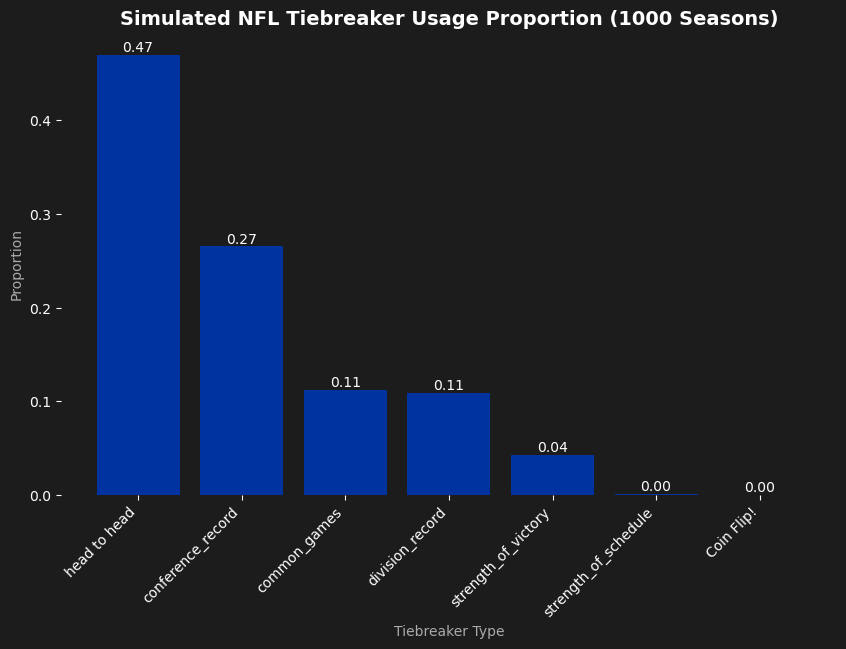

In [42]:
n = 1000

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()
for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

sorted_items = sorted(tb_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_items)
total_count = sum(counts)
proportions = [c / total_count for c in counts]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, proportions, color=BAR_BLUE)
plt.title(f"Simulated NFL Tiebreaker Usage Proportion ({n} Seasons)")
plt.xlabel("Tiebreaker Type")
plt.ylabel("Proportion")
plt.bar_label(bars, fmt="%.2f")
plt.xticks(rotation=45, ha="right")
plt.show()

Head to head is by far the most common tiebreaker used, accounting for the majority of ties broken. Division record and conference record come in next. The fact that most ties are resolved in the first 2-3 levels suggests the hierarchy rarely needs to go deep. Keep in mind that this simulation doesn't even cover the entire depth of the NFL's tiebreaker chain.

Let's now compare this to real NFL data, since 2002 as that's when the new tiebreaker rules started to apply.

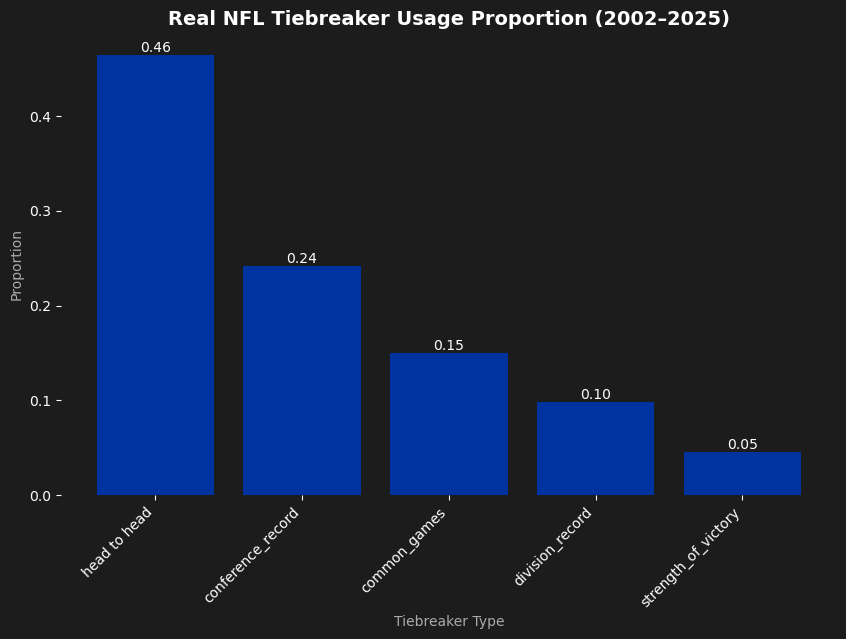

In [43]:
tb_counts_real = Counter()
fpi_counts_real = Counter()
field_count_real = Counter()

for year in range(2002, 2026):
    results_df_real, standings_df_real = build_real_season_dfs(year)
    if year in dfs:
        fpi_map = dict(zip(dfs[year]["Team"], dfs[year]["FPI"]))
        standings_df_real["FPI"] = standings_df_real["Team"].map(fpi_map)
    field_real, tbs_real, fpi_winners_real = playoff_field(standings_df_real, results_df_real)
    filtered_tbs_real = [tb for tb in tbs_real if tb != "win percentage diff"]
    tb_counts_real.update(Counter(filtered_tbs_real))
    if year in dfs:
        fpi_counts_real.update(Counter(fpi_winners_real))
    field_count_real.update(Counter(field_real["Team"]))

sorted_items_real = sorted(tb_counts_real.items(), key=lambda x: x[1], reverse=True)
labels_real, counts_real = zip(*sorted_items_real)
total_count_real = sum(counts_real)
proportions_real = [c / total_count_real for c in counts_real]

plt.figure(figsize=(10, 6))
bars_real = plt.bar(labels_real, proportions_real, color=BAR_BLUE)
plt.title("Real NFL Tiebreaker Usage Proportion (2002–2025)")
plt.xlabel("Tiebreaker Type")
plt.ylabel("Proportion")
plt.bar_label(bars_real, fmt="%.2f")
plt.xticks(rotation=45, ha="right")
plt.show()

**Note:** The real NFL data here spans 2002–2025 for tiebreaker usage counts, but FPI data is only available from 2015 onward. As a result, the tiebreaker distribution reflects the full historical range, while any FPI-based analysis in later cells is limited to 2015–2024.

### Does the higher FPI team usually win the tiebreaker? ###
We may know how tiebreakers are distributed, but how good are they at picking the "correct" team. If we assume that FPI is the end-all, be-all for determining 1 team is better than the other, how do the NFL's current tiebreaker set-up pick the "right" team? We will first look at our simulation and then the actual NFL results.

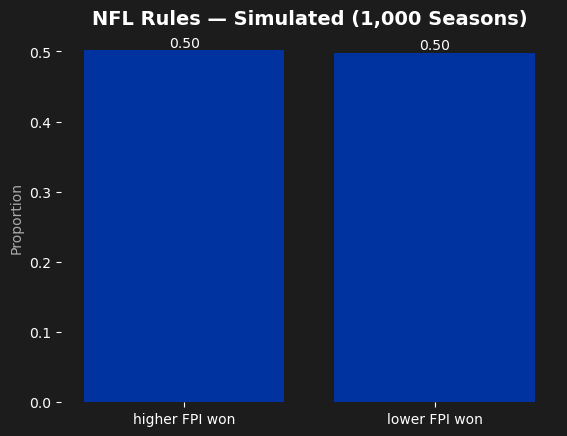

In [44]:
fpi_hist_df = pd.Series(fpi_counts)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_BLUE)
plt.ylabel("Proportion")
plt.title("NFL Rules — Simulated (1,000 Seasons)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

In simulation, the NFL's current tiebreaker rules pick the higher FPI team roughly 50% of the time, which is essentially no better than a coin flip. This makes sense as rules like head to head and division record are highly dependent on schedule and luck over a 17-game season, and don't strongly reflect true team quality.

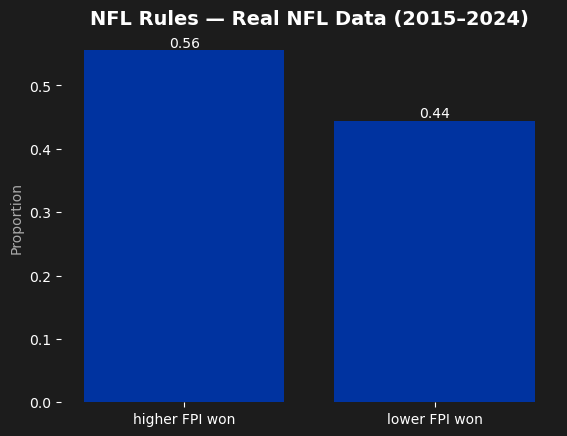

In [45]:
fpi_hist_df = pd.Series(fpi_counts_real)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_BLUE)
plt.ylabel("Proportion")
plt.title("NFL Rules — Real NFL Data (2015–2024)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

In [46]:
# does NFL rules pick the higher FPI team better than a coin flip?
higher_real_nfl = fpi_counts_real["higher FPI won"]
total_real_nfl  = sum(fpi_counts_real.values())

result = binomtest(higher_real_nfl, n=total_real_nfl, p=0.5, alternative="greater")
print(f"NFL Rules (Real): {higher_real_nfl}/{total_real_nfl} = {higher_real_nfl/total_real_nfl:.1%}")
print(f"Binomial test vs 50% — p-value: {result.pvalue:.4f}")
print(f"Statistically significant (α=0.05): {result.pvalue < 0.05}")

NFL Rules (Real): 35/63 = 55.6%
Binomial test vs 50% — p-value: 0.2250
Statistically significant (α=0.05): False


The NFL rules results are not statistically significant from the 50% mark that we found in our simulation. This by itself doesn't really "prove" anything, but it shows that the NFL's tiebreakers have been unable to have a statistically different outcome from a coin toss when it comes to picking the higher FPI team in a tiebreaker.

### What if we use total margin (ie, Point Differential) as a tiebreaker? ###

We can see that the current NFL tiebreaker chain fails to pick the higher FPI team with much certainty. In fact, in our simulation it's no more effective than simply just doing a coin flip. Seeing the point of a tiebreaker is to pick the better team, we should experiment with some alternate methods.

The logical next step would be using Point Differential. There's 2 main advantages to Point Differential. One being it's rare to tie on point differential in the first place, which will lead to a less complex hiearchy for our tiebreakers. The other advantage is it rewards teams for winning definitively, rather than winning by "scraping by". In theory, the better team will win by a larger average margin than a worse team.

As a failsafe, we will implement strength of victory as a second tiebreaker incase total margin is tied.

In [57]:
n = 1000
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "total_margin") #tie_breaker is just point differential

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

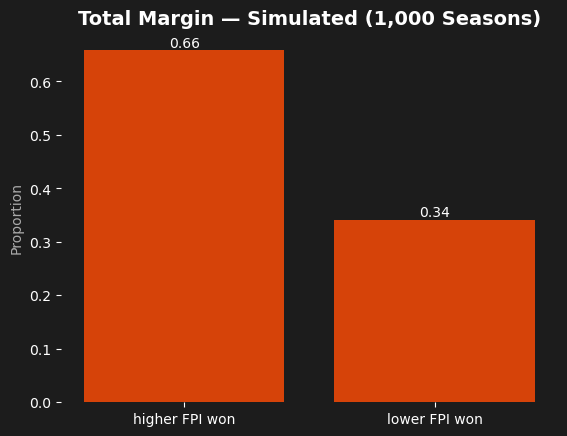

In [58]:
fpi_hist_df = pd.Series(fpi_counts)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_ORANGE)
plt.ylabel("Proportion")
plt.title("Total Margin — Simulated (1,000 Seasons)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

Switching to total margin as the primary tiebreaker significantly improves accuracy. The higher FPI team wins roughly 66% of tiebreakers compared to ~50% under NFL rules. Point differential captures cumulative team performance across the season, making it a much stronger signal of true quality.

In [59]:
tb_counts_real = Counter()
fpi_counts_real = Counter()
field_count_real = Counter()

for year in range(2015, 2026):
    results_df, standings_df = build_real_season_dfs(year)

    if year in dfs:
        fpi_map = dict(zip(dfs[year]["Team"], dfs[year]["FPI"]))
        standings_df["FPI"] = standings_df["Team"].map(fpi_map)

    field, tiebreakers, fpi_winners = playoff_field(
        standings_df,
        results_df,
        mode="total_margin"
    )

    tb_counts_real.update(Counter(tiebreakers))
    fpi_counts_real.update(Counter(fpi_winners))
    field_count_real.update(Counter(field["Team"]))

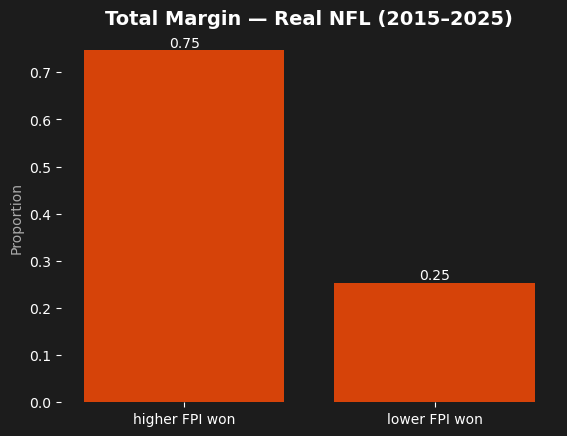

In [62]:
fpi_hist_df = pd.Series(fpi_counts_real)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_ORANGE)
plt.ylabel("Proportion")
plt.title("Total Margin — Real NFL (2015–2025)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

In [63]:
# is the sim total margin result significantly different from the real NFL result?
higher_sim_total  = fpi_counts["higher FPI won"]
total_sim_total   = sum(fpi_counts.values())
higher_real_total = fpi_counts_real["higher FPI won"]
total_real_total  = sum(fpi_counts_real.values())

stat, p_val = proportions_ztest([higher_sim_total, higher_real_total], [total_sim_total, total_real_total])
print(f"Total Margin — Sim: {higher_sim_total/total_sim_total:.1%}, Real: {higher_real_total/total_real_total:.1%}")
print(f"Two-proportion z-test — p-value: {p_val:.4f}")
print(f"Significantly different (α=0.05): {p_val < 0.05}")

Total Margin — Sim: 65.8%, Real: 74.6%
Two-proportion z-test — p-value: 0.1187
Significantly different (α=0.05): False


The real NFL data backs up the simulation, as total margin picks the higher FPI team around 75% of the time. The improvement over NFL rules is even more pronounced here than in simulation, suggesting that point differential is a strong indicator of true team strength in real seasons.

And again, applying the total margin ruleset to real NFL data doesn't lead to statistically significantly different results compared to our simulation. What's interesting is when applied to real NFL data, the proportion goes up by .09.

### What if we cap the margin?

There's one big issue with Total Margin, it rewards teams for running up the score. In NFL culture, running up the score is frowned upon, and from a business perspective it can prolong games and create TV scheduling conflicts. A natural fix is to introduce a "capped margin", where the margin counted per game is capped at some value X. So whether a team wins by X or by 45, they get the same credit. This discourages score inflation while still rewarding dominant wins.

As a failsafe, we will implement strength of victory as a second tiebreaker in case the capped margin is tied.

In [52]:
n = 1000
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed, tm_cap=14)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode="capped_margin")

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

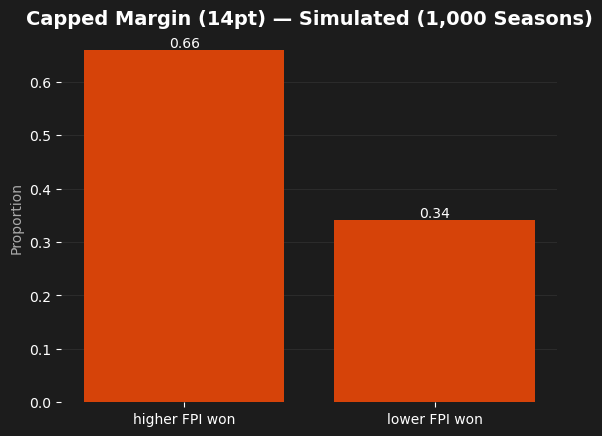

In [53]:
fpi_hist_df = pd.Series(fpi_counts)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_ORANGE)
plt.ylabel("Proportion")
plt.title("Capped Margin (14pt) — Simulated (1,000 Seasons)")
plt.bar_label(bars, fmt="%.2f")
plt.gca().yaxis.grid(True)
plt.gca().set_axisbelow(True)
plt.show()

Capping the margin at 14 points still picks the higher FPI team around 64% of the time in simulation, nearly matching total margin (66%). That's a meaningful improvement over NFL rules (50%) while avoiding the "run up the score" problem. Let's see if this holds on real NFL data.

In [54]:
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

tm_cap = 14

for year in range(2015, 2026):
    results_df, standings_df = build_real_season_dfs(year, tm_cap=tm_cap)

    if year in dfs:
        fpi_map = dict(zip(dfs[year]["Team"], dfs[year]["FPI"]))
        standings_df["FPI"] = standings_df["Team"].map(fpi_map)

    field, tiebreakers, fpi_winners = playoff_field(
        standings_df,
        results_df,
        mode="capped_margin"
    )

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))


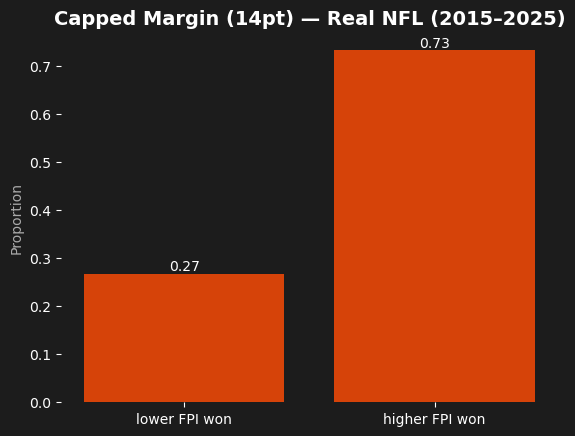

In [55]:
fpi_hist_df = pd.Series(fpi_counts)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_ORANGE)
plt.ylabel("Proportion")
plt.title(f"Capped Margin ({tm_cap}pt) — Real NFL (2015–2025)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

Again, this holds up pretty well. It's not as consistent as total margin, but I think the 3% difference is a fair trade off for the cons that total margin would bring.

### What would be the optimal cap to maximize the higher FPI team winning?
The only problem with the capped margin method is we don't know what the optimal point is to set the cap. We don't need to completely match the results from total margin, but we want it to be within around 2% of the accuracy of total margin. So the question becomes, how low can we set the cap while being within 2% of total margin?

In [27]:
# Better tiebreaking procedures
# Compare multiple tm_cap values on the same FPI / Schedule / sim seeds
n = 1000

tm_caps = [50, 40, 30, 25, 20, 17, 14, 10, 7, 5]

df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=12)
schedule_df = generate_schedule(df_seeded, seed=1)

cap_results = []

for cap in tm_caps:
    tb_counts = Counter()
    fpi_counts = Counter()
    field_count = Counter()

    for sim_seed in range(1, n + 1):
        results_df, standings_df = simulate_season(
            df_seeded, schedule_df, seed=sim_seed, tm_cap=cap
        )

        field, tiebreakers, fpi_winners = playoff_field(
            standings_df, results_df, mode="capped_margin"
        )

        tb_counts.update(Counter(tiebreakers))
        fpi_counts.update(Counter(fpi_winners))
        field_count.update(Counter(field["Team"]))

    total_fpi_tiebreaks = sum(fpi_counts.values())
    higher_fpi_wins = fpi_counts["higher FPI won"]
    higher_fpi_win_pct = higher_fpi_wins / total_fpi_tiebreaks if total_fpi_tiebreaks > 0 else 0

    cap_results.append({
        "tm_cap": cap,
        "higher_FPI_won": higher_fpi_wins,
        "total_FPI_tiebreaks": total_fpi_tiebreaks,
        "higher_FPI_win_pct": higher_fpi_win_pct
    })

cap_results_df = pd.DataFrame(cap_results)
print(cap_results_df)

   tm_cap  higher_FPI_won  total_FPI_tiebreaks  higher_FPI_win_pct
0      50            4918                 7336            0.670393
1      40            4918                 7336            0.670393
2      30            4919                 7336            0.670529
3      25            4917                 7336            0.670256
4      20            4866                 7336            0.663304
5      17            4878                 7336            0.664940
6      14            4866                 7336            0.663304
7      10            4790                 7336            0.652944
8       7            4713                 7336            0.642448
9       5            4552                 7336            0.620502


Results show accuracy stays flat from cap=50 down to about cap=20, then drops off steadily below that. A cap of 10 gives roughly 65% accuracy, which ends up being within ~2% of uncapped total margin. It's also low enough to prevent any real "running up the score" type moments. We'll use 10 as our cap going forward and validate it on real NFL data.

In [37]:
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

tm_cap = 10

for year in range(2015, 2026):
    results_df, standings_df = build_real_season_dfs(year, tm_cap=tm_cap)

    if year in dfs:
        fpi_map = dict(zip(dfs[year]["Team"], dfs[year]["FPI"]))
        standings_df["FPI"] = standings_df["Team"].map(fpi_map)

    field, tiebreakers, fpi_winners = playoff_field(
        standings_df,
        results_df,
        mode="capped_margin"
    )

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

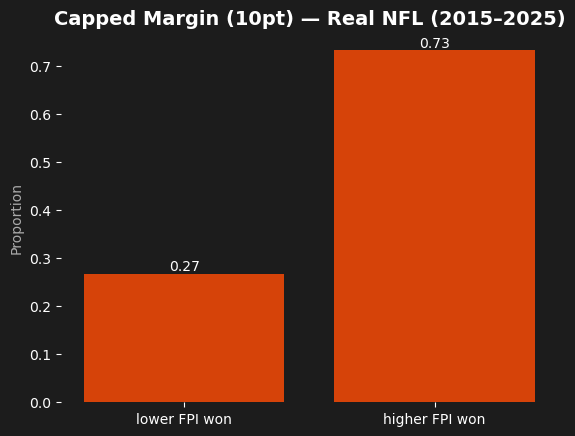

In [38]:
fpi_hist_df = pd.Series(fpi_counts)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values, color=BAR_ORANGE)
plt.ylabel("Proportion")
plt.title(f"Capped Margin ({tm_cap}pt) — Real NFL (2015–2025)")
plt.bar_label(bars, fmt="%.2f")
plt.show()

In [39]:
from statsmodels.stats.proportion import proportions_ztest

# is the sim capped margin result significantly different from the real NFL result?
higher_sim_cap  = fpi_counts["higher FPI won"]
total_sim_cap   = sum(fpi_counts.values())
higher_real_cap = fpi_counts_real["higher FPI won"]
total_real_cap  = sum(fpi_counts_real.values())

stat, p_val = proportions_ztest([higher_sim_cap, higher_real_cap], [total_sim_cap, total_real_cap])
print(f"Capped Margin ({tm_cap}pt) — Sim: {higher_sim_cap/total_sim_cap:.1%}, Real: {higher_real_cap/total_real_cap:.1%}")
print(f"Two-proportion z-test — p-value: {p_val:.4f}")
print(f"Significantly different (α=0.05): {p_val < 0.05}")

Capped Margin (10pt) — Sim: 73.2%, Real: 55.6%
Two-proportion z-test — p-value: 0.0323
Significantly different (α=0.05): True


# Identifying Best Team #

### How often does the #1 FPI team (per conference) end up being a 1 seed within our simulations? ###


Coin flip! Between ['Green Bay Packers', 'Arizona Cardinals']


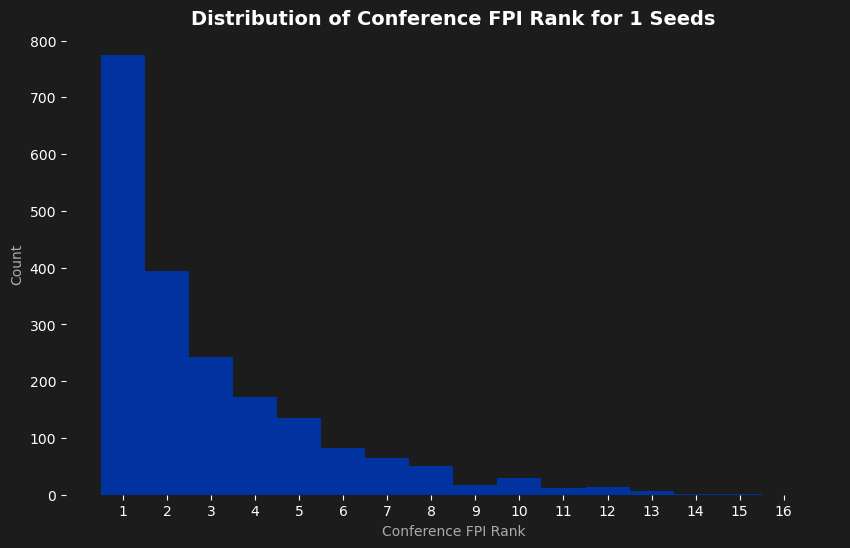

In [33]:
one_seed_ranks = []

n = 1000
for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    standings_df["Conf_FPI_Rank"] = (
        standings_df.groupby("Conference")["FPI"]
        .rank(method="first", ascending=False).astype(int))
    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
    one_seeds = field[field["Seed"] == 1]["Team"]
    one_seed_rows = standings_df.loc[
        standings_df["Team"].isin(one_seeds), ["Team", "Conference", "Conf_FPI_Rank"]].copy()
    one_seed_ranks.append(one_seed_rows)

one_seed_ranks_df = pd.concat(one_seed_ranks, ignore_index=True)

plt.figure(figsize=(10, 6))
plt.hist(one_seed_ranks_df["Conf_FPI_Rank"], bins=np.arange(1, 18) - 0.5, color=BAR_BLUE)
plt.xticks(range(1, 17))
plt.xlabel("Conference FPI Rank")
plt.ylabel("Count")
plt.title("Distribution of Conference FPI Rank for 1 Seeds")
plt.show()

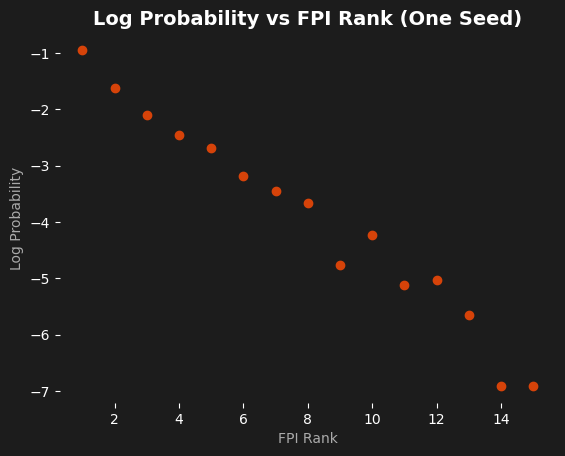

R² = 0.972 — the linear fit in log space explains 97.2% of the variance, showing a near-exponential decay.


In [35]:
rank_counts = one_seed_ranks_df["Conf_FPI_Rank"].value_counts().sort_index()
rank_probs = rank_counts / rank_counts.sum()

plt.figure()
plt.scatter(rank_probs.index, np.log(rank_probs), color=BAR_ORANGE)
plt.xlabel("FPI Rank")
plt.ylabel("Log Probability")
plt.title("Log Probability vs FPI Rank (One Seed)")
plt.show()

slope, intercept, r, p, se = linregress(rank_probs.index, np.log(rank_probs))

print(f"R² = {r**2:.3f} — the linear fit in log space explains {r**2*100:.1f}% of the variance, showing a near-exponential decay.")

In [ ]:
from scipy.stats import chisquare
from scipy.optimize import curve_fit

observed = one_seed_ranks_df["Conf_FPI_Rank"].value_counts().reindex(range(1, 17), fill_value=0).values
ranks = np.arange(1, 17)
observed_probs = observed / observed.sum()

# fit a power law: a * x^(-b)
def power_law(x, a, b):
    return a * x**(-b)

popt, _ = curve_fit(power_law, ranks, observed_probs)
expected_power = power_law(ranks, *popt)
expected_power = expected_power / expected_power.sum() * observed.sum()

chi2, p_val = chisquare(f_obs=observed, f_exp=expected_power)
print(f"Power law fit — a={popt[0]:.3f}, b={popt[1]:.3f}")
print(f"Chi-square: {chi2:.3f}, p-value: {p_val:.4f}")
print(f"Good fit (p > 0.05): {p_val > 0.05}")

Keep in mind for real life results, there's not much information we can extrapolate. For starters, there's just not much data, as FPI was only created in 2013. Also, FPI is not a purely preseason metric — it is influenced by in-season performance, so it ends up reflecting how strong teams actually were, not just predicting who would be good. Because of that, this does not really prove that FPI "predicts" 1 seeds. It just shows that the teams that become 1 seeds are usually among the strongest teams by FPI.

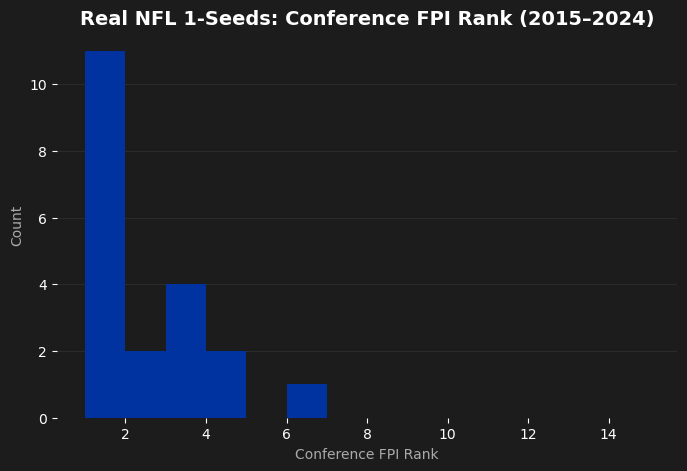

In [36]:
one_seed_fpi_history = []

for year in range(2015, 2025):
    results, standings = build_real_season_dfs(year)
    results["Home"] = results["Home"].replace(corrected_teams)
    results["Away"] = results["Away"].replace(corrected_teams)
    results["Winner"] = results["Winner"].replace(corrected_teams)
    results["Loser"] = results["Loser"].replace(corrected_teams)
    standings["Team"] = standings["Team"].replace(corrected_teams)
    standings = standings.drop(columns=["FPI"])
    standings = standings.merge(dfs[year][["Team", "FPI"]], on="Team", how="left")
    standings["FPI_Rank"] = standings["FPI"].rank(method="min", ascending=False).astype(int)
    standings["Conf_FPI_Rank"] = (
        standings.groupby("Conference")["FPI"]
        .rank(method="first", ascending=False).astype(int)
    )
    field, tiebreakers, fpi_winners = playoff_field(standings, results)
    one_seeds = field.loc[field["Seed"] == 1, "Team"]
    rows = standings.loc[
        standings["Team"].isin(one_seeds),
        ["Team", "Conference", "FPI", "FPI_Rank", "Conf_FPI_Rank"]
    ].copy()
    rows["Year"] = year
    one_seed_fpi_history.append(rows)

one_seed_fpi_history_df = pd.concat(one_seed_fpi_history, ignore_index=True)

plt.figure(figsize=(8, 5))
plt.hist(one_seed_fpi_history_df["Conf_FPI_Rank"], bins=range(1, 16), color=BAR_BLUE)
plt.xlabel("Conference FPI Rank")
plt.ylabel("Count")
plt.title("Real NFL 1-Seeds: Conference FPI Rank (2015–2024)")
plt.gca().yaxis.grid(True)
plt.gca().set_axisbelow(True)
plt.show()


### How does season length affect the proportion of the true #1 team being the 1 seed? ###

In [69]:
CACHE = "season_length_results.csv"

if os.path.exists(CACHE):
    results_df_summary = pd.read_csv(CACHE)
    print("Loaded from cache")
else:
    season_lengths = [12, 16, 17, 34, 50, 100, 250, 500, 1000, 2500, 5000, 10000]
    n_sims = 250
    results = []
    df = pd.read_csv("FPI-1-11-26.csv")

    for season_length in season_lengths:
        
        fpi_win_corrs = []
        one_seed_fpi_ranks = []
        best_team_one_seed_count = 0
        best_team_sb_count = 0
        
        for sim_seed in range(1, n_sims + 1):
            
            df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
            schedule_df = generate_schedule(df_seeded, seed=sim_seed, season_length=season_length)
            results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
            field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)
            playoff_results_df, sb_winner = simulate_playoffs(df_seeded, field, seed=sim_seed)
            
            standings_temp = standings_df.copy()
            standings_temp["FPI_Rank"] = standings_temp["FPI"].rank(method="first", ascending=False)
            
            fpi_win_corrs.append(standings_temp["FPI"].corr(standings_temp["Wins"]))
            
            one_seed_rows = field[field["Seed"] == 1].merge(standings_temp[["Team", "FPI_Rank"]], on="Team", how="left")
            one_seed_fpi_ranks.extend(one_seed_rows["FPI_Rank"].tolist())
            
            best_fpi_team = standings_temp.sort_values("FPI", ascending=False)["Team"].iloc[0]
            
            if best_fpi_team in field[field["Seed"] == 1]["Team"].values:
                best_team_one_seed_count += 1
                
            if sb_winner == best_fpi_team:
                best_team_sb_count += 1
        
        results.append({"Season_Length": season_length,
            "Avg_FPI_Wins_Corr": np.mean(fpi_win_corrs), "Avg_1_Seed_FPI_Rank": np.mean(one_seed_fpi_ranks),
            "Best_FPI_Team_1_Seed_Prob": best_team_one_seed_count / n_sims, "Best_FPI_Team_SB_Prob": best_team_sb_count / n_sims})
        print("Done with", season_length)

    results_df_summary = pd.DataFrame(results)
    results_df_summary.to_csv(CACHE, index=False)
    print("Saved to cache")

Loaded from cache


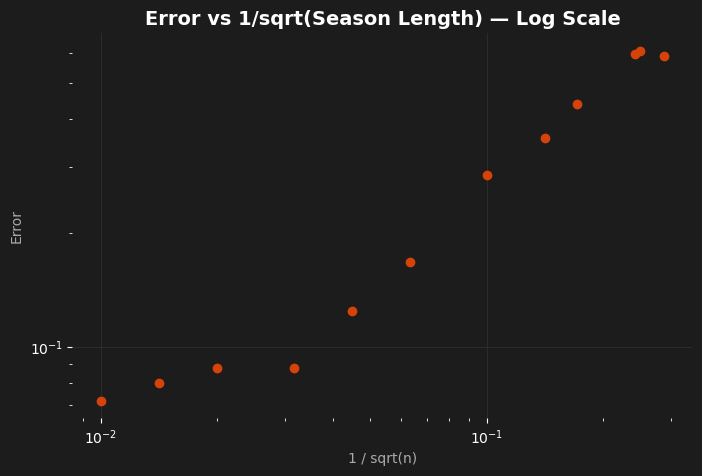

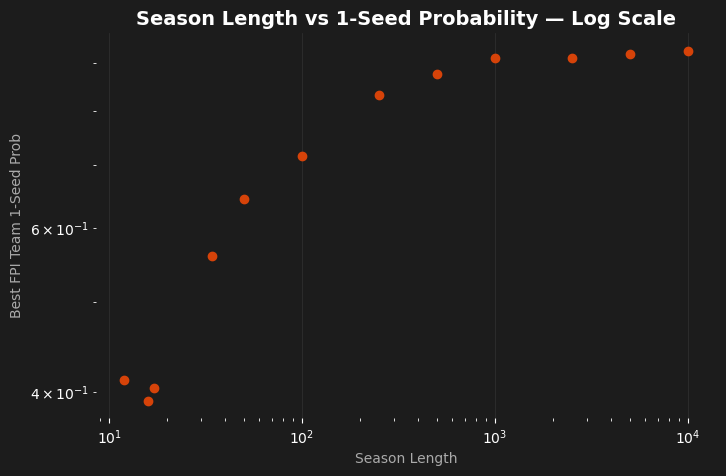

In [70]:
results_df_summary["Error"] = 1 - results_df_summary["Best_FPI_Team_1_Seed_Prob"]
results_df_summary["Inv_Sqrt_n"] = 1 / np.sqrt(results_df_summary["Season_Length"])

# log-log: error vs 1/sqrt(n)
plt.figure(figsize=(8, 5))
plt.scatter(results_df_summary["Inv_Sqrt_n"], results_df_summary["Error"], color=BAR_ORANGE)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("1 / sqrt(n)")
plt.ylabel("Error")
plt.title("Error vs 1/sqrt(Season Length) — Log Scale")
plt.gca().yaxis.grid(True)
plt.gca().xaxis.grid(True)
plt.gca().set_axisbelow(True)
plt.show()

# log-log: season length vs best team 1-seed prob
plt.figure(figsize=(8, 5))
plt.scatter(results_df_summary["Season_Length"], results_df_summary["Best_FPI_Team_1_Seed_Prob"], color=BAR_ORANGE)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Season Length")
plt.ylabel("Best FPI Team 1-Seed Prob")
plt.title("Season Length vs 1-Seed Probability — Log Scale")
plt.gca().yaxis.grid(True)
plt.gca().xaxis.grid(True)
plt.gca().set_axisbelow(True)
plt.show()

# Prediction and Forecasting #

### How well does the previous season’s FPI predict the next season’s playoff field? ###


